# AI Project Management: Comprehensive Benchmark Analysis
## LLM Intelligence vs. GNN & Traditional Allocation Strategies

This notebook follows a structured analysis flow for the thesis:
1. **Phase 1: Subjective LLM Analysis** - Task quality and technical depth (Completeness).
2. **Phase 2: Global Methodology Analysis** - GNN vs. Traditional logic independently of models.
3. **Phase 3: Detailed Model Allocation** - Precision, Recall, and F1-Score breakdown.
4. **Phase 4: Unified Benchmarking** - The intersection of Quality and Allocation Accuracy.
5. **Phase 5: Synthesis** - Statistical correlations between task detail and success.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Path configuration
gnn_path = 'OUTPUT/eval_project_managment/decomposition_eval_gnn.csv'
trad_path = 'OUTPUT/eval_project_managment/decomposition_eval_traditional.csv'

# Load data
gnn_df = pd.read_csv(gnn_path)
trad_df = pd.read_csv(trad_path)

def get_f1_series(df):
    eval_df = df.dropna(subset=['PM Ground Truth Assignee'])
    res = {}
    for model in eval_df['Model'].unique():
        m_data = eval_df[eval_df['Model'] == model]
        _, _, f, _ = precision_recall_fscore_support(m_data['PM Ground Truth Assignee'], m_data['AI Assignee'], average='weighted', zero_division=0)
        res[model] = f
    return pd.Series(res)

print('Datasets loaded successfully from OUTPUT/eval_project_managment/')

Datasets loaded successfully from OUTPUT/eval_project_managment/


## Phase 1: Subjective PM Evaluation (The Brain)
Evaluating the LLMs on **Quality (PM Score)** and **Technical Depth (Completeness)**.

,PM Score (1-5),Completeness (1-5)
Model,,
gemma4:e4b,4.889,4.622
qwen3.6:27b,4.851,5.000
qwen3.5:27b,4.829,4.714
gemma4:26b,4.635,4.019
gemma3:27b,4.427,3.773
gpt-oss:20b,4.380,3.563
qwen3.5:9b,4.107,2.336
gemma3:4b,3.466,1.621
Llama3.2:latest,3.111,1.467


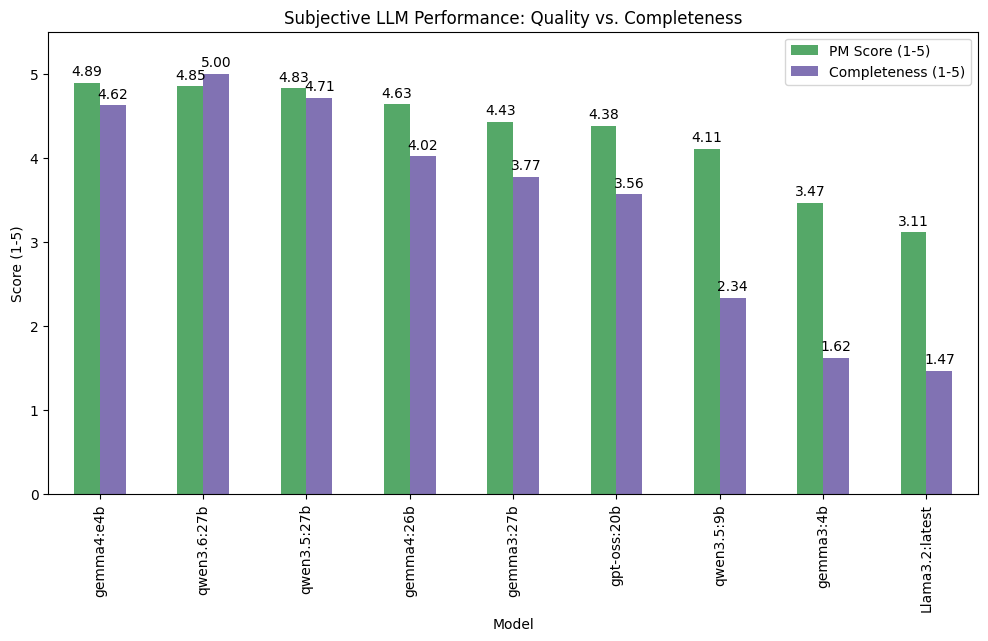

In [2]:
llm_stats = gnn_df.groupby('Model')[['PM Score (1-5)', 'Completeness (1-5)']].mean().sort_values('PM Score (1-5)', ascending=False)
display(llm_stats.round(3))

ax = llm_stats.plot(kind='bar', figsize=(12, 6), color=['#55A868', '#8172B3'])
plt.title('Subjective LLM Performance: Quality vs. Completeness')
plt.ylabel('Score (1-5)')
plt.ylim(0, 5.5)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.show()

## Phase 2: Overall Methodology Performance (GNN vs. Traditional)
Comparing the inherent effectiveness of the two assignment systems.

,Method,Accuracy,F1-Score
0,GNN,0.635,0.612
1,Traditional,0.580,0.581


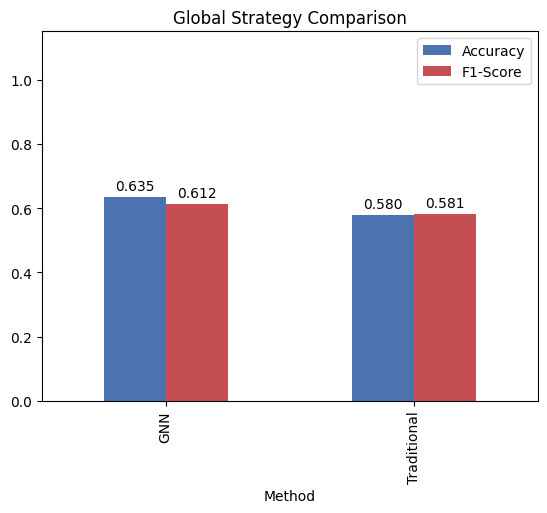

In [3]:
def global_metrics(df, label):
    eval_df = df.dropna(subset=['PM Ground Truth Assignee'])
    p, r, f, _ = precision_recall_fscore_support(eval_df['PM Ground Truth Assignee'], eval_df['AI Assignee'], average='weighted', zero_division=0)
    return {'Method': label, 'Accuracy': accuracy_score(eval_df['PM Ground Truth Assignee'], eval_df['AI Assignee']), 'F1-Score': f}

global_summary = pd.DataFrame([global_metrics(gnn_df, 'GNN'), global_metrics(trad_df, 'Traditional')])
display(global_summary.round(3))

ax = global_summary.set_index('Method')[['Accuracy', 'F1-Score']].plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Global Strategy Comparison')
plt.ylim(0, 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.show()

## Phase 3: Detailed Allocation Metrics per Model
Precision, Recall, and F1-Score for each LLM under both frameworks.

In [4]:
def detailed_metrics(df):
    eval_df = df.dropna(subset=['PM Ground Truth Assignee'])
    res = {}
    for model in eval_df['Model'].unique():
        m_data = eval_df[eval_df['Model'] == model]
        p, r, f, _ = precision_recall_fscore_support(m_data['PM Ground Truth Assignee'], m_data['AI Assignee'], average='weighted', zero_division=0)
        res[model] = {'Precision': p, 'Recall': r, 'F1': f}
    return pd.DataFrame(res).T

gnn_metrics = detailed_metrics(gnn_df)
print('GNN Detailed Metrics:')
display(gnn_metrics.round(3))

GNN Detailed Metrics:


,Precision,Recall,F1
gemma4:e4b,0.565,0.600,0.570
gemma4:26b,0.618,0.673,0.611
qwen3.5:9b,0.480,0.536,0.492
qwen3.5:27b,0.628,0.657,0.633
qwen3.6:27b,0.684,0.701,0.686
Llama3.2:latest,0.832,0.644,0.625
gemma3:4b,0.787,0.707,0.731
gemma3:27b,0.627,0.667,0.626
gpt-oss:20b,0.670,0.634,0.633


## Phase 4: Unified Multi-Metric Model Comparison
This plot merges Subjective Scores (1-5) and Allocation F1-Scores (0-1) to show the complete picture.

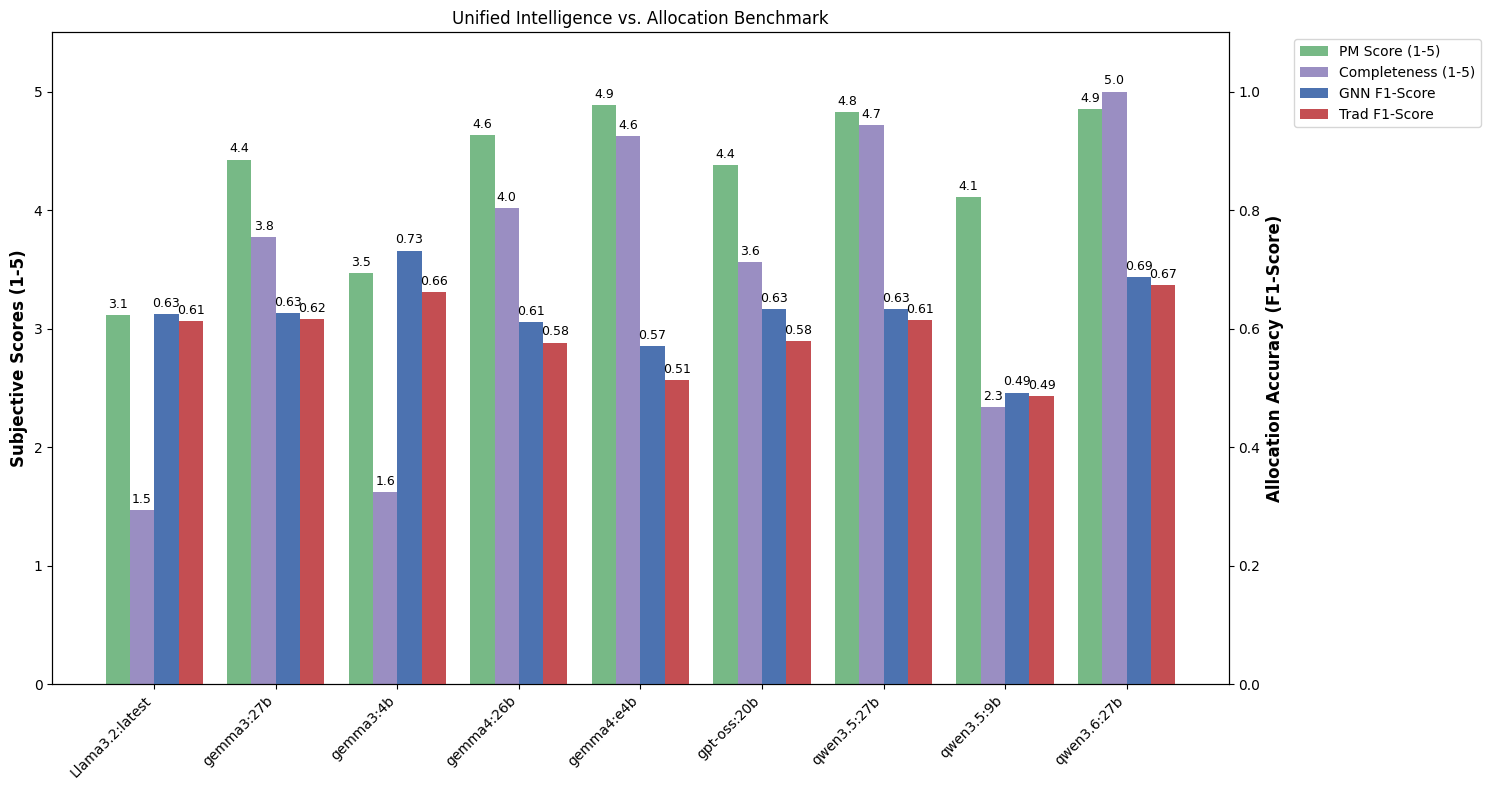

In [5]:
plot_df = pd.DataFrame({
    'PM Score': llm_stats['PM Score (1-5)'],
    'Completeness': llm_stats['Completeness (1-5)'],
    'GNN F1': get_f1_series(gnn_df),
    'Trad F1': get_f1_series(trad_df)
})

fig, ax1 = plt.subplots(figsize=(15, 8))
x = np.arange(len(plot_df))
width = 0.2

b1 = ax1.bar(x - width*1.5, plot_df['PM Score'], width, label='PM Score (1-5)', color='#55A868', alpha=0.8)
b2 = ax1.bar(x - width/2, plot_df['Completeness'], width, label='Completeness (1-5)', color='#8172B3', alpha=0.8)
ax1.set_ylabel('Subjective Scores (1-5)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 5.5)
ax1.bar_label(b1, fmt='%.1f', padding=3, fontsize=9)
ax1.bar_label(b2, fmt='%.1f', padding=3, fontsize=9)

ax2 = ax1.twinx()
b3 = ax2.bar(x + width/2, plot_df['GNN F1'], width, label='GNN F1-Score', color='#4C72B0')
b4 = ax2.bar(x + width*1.5, plot_df['Trad F1'], width, label='Trad F1-Score', color='#C44E52')
ax2.set_ylabel('Allocation Accuracy (F1-Score)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.bar_label(b3, fmt='%.2f', padding=3, fontsize=9)
ax2.bar_label(b4, fmt='%.2f', padding=3, fontsize=9)

plt.title('Unified Intelligence vs. Allocation Benchmark')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df.index, rotation=45, ha='right')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Phase 5: Synthesis & Correlation
Determining if higher task detail (Completeness) statistically drives allocation success.

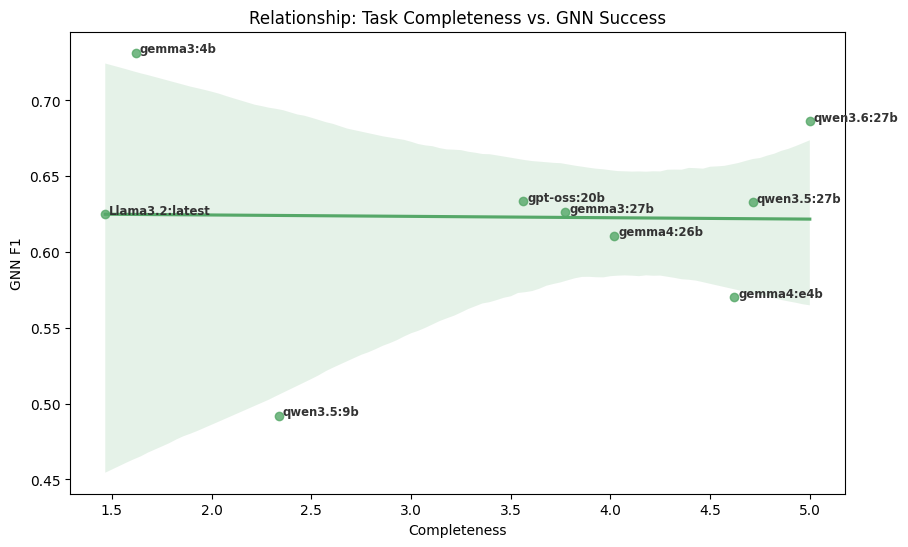

Correlation Coefficient: -0.02


In [6]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=plot_df, x='Completeness', y='GNN F1', color='#55A868')

# Add labels to each point marking the Model name
for idx, row in plot_df.iterrows():
    ax.text(row['Completeness'] + 0.02, row['GNN F1'], idx, 
            horizontalalignment='left', size='small', color='#333333', weight='semibold')

plt.title('Relationship: Task Completeness vs. GNN Success')
plt.show()
print(f"Correlation Coefficient: {plot_df['Completeness'].corr(plot_df['GNN F1']):.2f}")

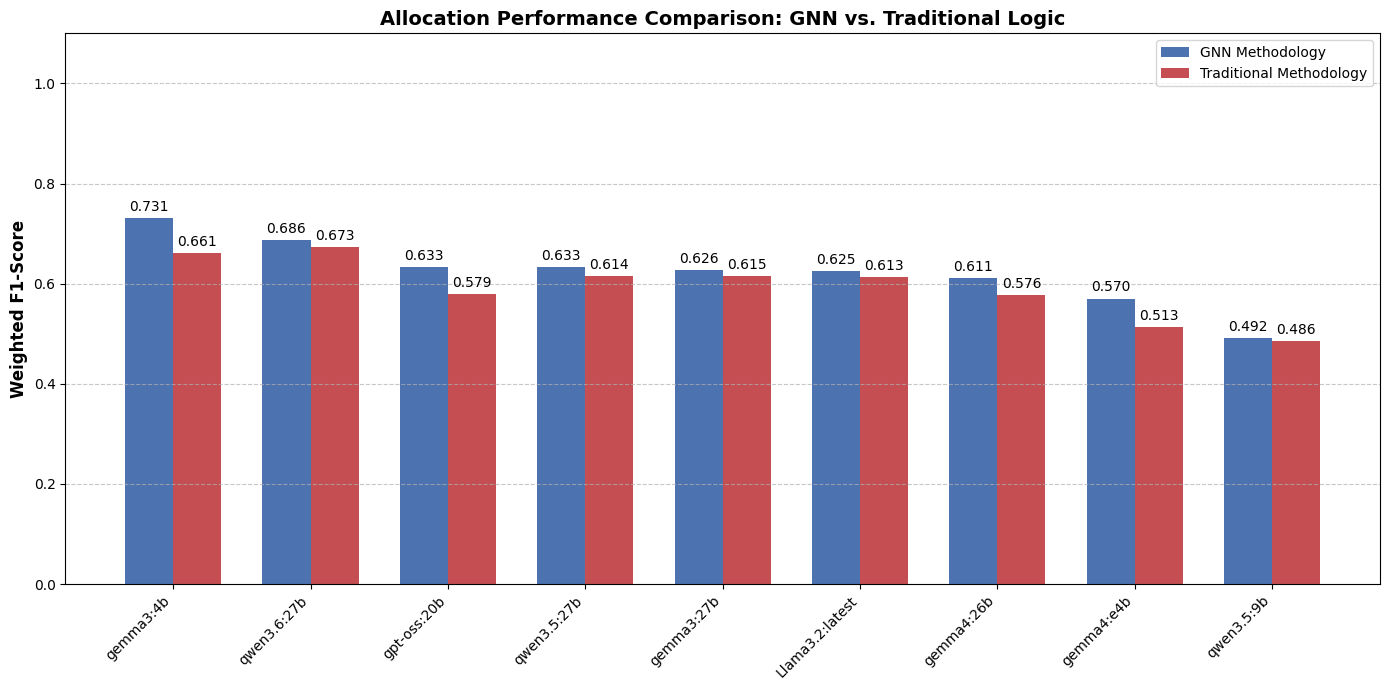

F1-Score Comparison Table:


,GNN F1,Traditional F1
gemma3:4b,0.731,0.661
qwen3.6:27b,0.686,0.673
gpt-oss:20b,0.633,0.579
qwen3.5:27b,0.633,0.614
gemma3:27b,0.626,0.615
Llama3.2:latest,0.625,0.613
gemma4:26b,0.611,0.576
gemma4:e4b,0.570,0.513
qwen3.5:9b,0.492,0.486


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

gnn_df = pd.read_csv(gnn_path)
trad_df = pd.read_csv(trad_path)

# 2. Calculate Weighted F1-Scores per Model
def calculate_f1_scores(df):
    eval_df = df.dropna(subset=['PM Ground Truth Assignee'])
    results = {}
    for model in eval_df['Model'].unique():
        m_data = eval_df[eval_df['Model'] == model]
        f1 = f1_score(m_data['PM Ground Truth Assignee'], m_data['AI Assignee'], 
                      average='weighted', zero_division=0)
        results[model] = f1
    return pd.Series(results)

gnn_f1 = calculate_f1_scores(gnn_df)
trad_f1 = calculate_f1_scores(trad_df)

# 3. Create Grouped Bar Chart
plot_data = pd.DataFrame({'GNN F1': gnn_f1, 'Traditional F1': trad_f1}).sort_values('GNN F1', ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(plot_data))
width = 0.35

b1 = ax.bar(x - width/2, plot_data['GNN F1'], width, label='GNN Methodology', color='#4C72B0')
b2 = ax.bar(x + width/2, plot_data['Traditional F1'], width, label='Traditional Methodology', color='#C44E52')

ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)

# 4. Formatting for Thesis
ax.set_ylabel('Weighted F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Allocation Performance Comparison: GNN vs. Traditional Logic', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('final_f1_comparison.png', dpi=300)
plt.show()

# 5. Display Table Summary
print("F1-Score Comparison Table:")
display(plot_data.round(3))